# Problem Statement

## Financial institutions face significant losses due to fraudulent transactions. Detecting fraud in real-time is challenging due to the high volume of transactions and the evolving nature of fraudulent behavior.

## This project aims to analyze transaction data to identify fraud patterns and develop a rule-based risk scoring system that helps in early detection of suspicious transactions.

## To guide the analysis, the following key questions will be addressed:

When does fraud occur most frequently?

Which transactions are more likely to be fraudulent?

What behavioral patterns indicate fraudulent activity?

Which users exhibit suspicious transaction behavior?

In [ ]:
#STEP 1: Clean Data Loading

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/sample_data.csv")

# Display first few rows
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V335,V336,V337,V338,V339,hour,amt_bucket,high_risk,medium_risk,risk_score
0,3081804,0,1959738,50.0,R,5772,298.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,16,"(45.0, 75.0]",0,0,0
1,2993209,0,200119,75.0,W,16079,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,7,"(45.0, 75.0]",0,0,0
2,3074803,0,1862544,250.0,R,10486,514.0,150.0,mastercard,219.0,...,0.0,0.0,0.0,0.0,0.0,13,"(135.95, 4829.95]",0,0,0
3,3027691,0,1007053,34.0,W,10447,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,15,"(0.291, 45.0]",0,0,0
4,3053483,0,1507472,77.0,W,1764,158.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,10,"(75.0, 135.95]",0,0,0


In [ ]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V335', 'V336', 'V337', 'V338', 'V339', 'hour', 'amt_bucket',
       'high_risk', 'medium_risk', 'risk_score'],
      dtype='object', length=399)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 399 entries, TransactionID to risk_score
dtypes: float64(376), int64(8), object(15)
memory usage: 15.2+ MB


In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,4886
1,114


In [ ]:
# Remove pre-engineered columns
cols_to_drop = ['hour', 'amt_bucket', 'high_risk', 'medium_risk', 'risk_score']

df = df.drop(columns=cols_to_drop)

df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3081804,0,1959738,50.0,R,5772,298.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2993209,0,200119,75.0,W,16079,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3074803,0,1862544,250.0,R,10486,514.0,150.0,mastercard,219.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3027691,0,1007053,34.0,W,10447,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3053483,0,1507472,77.0,W,1764,158.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3081804,0,1959738,50.0,R,5772,298.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2993209,0,200119,75.0,W,16079,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3074803,0,1862544,250.0,R,10486,514.0,150.0,mastercard,219.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3027691,0,1007053,34.0,W,10447,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3053483,0,1507472,77.0,W,1764,158.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Structure Understanding

The dataset consists of transaction-level data with multiple features representing transaction details, card information, and anonymized variables.

**Target Variable**

isFraud: Indicates whether a transaction is fraudulent (1) or not (0)

**Transaction Features**

TransactionID: Unique identifier for each transaction
TransactionDT: Time of transaction (in seconds from a reference point)
TransactionAmt: Transaction amount

**Product Information**

ProductCD: Product category associated with the transaction

**Card Information** (Proxy for User)

card1, card2, card3, card4, card5: Encoded card-related features that can be used to identify transaction patterns and user behavior

**Anonymized Features**

V1 – V339: Engineered and anonymized features provided in the dataset, likely representing aggregated behavioral or transactional patterns

**Data Characteristics**

The dataset is highly imbalanced, with fraudulent transactions forming a small percentage of total transactions
The presence of anonymized features suggests underlying complex patterns that can help in identifying fraud

In [ ]:
# STEP 3: Data Quality Check

In [ ]:
# missing values
missing_values = df.isnull().sum()

In [ ]:
missing_values[missing_values > 0].sort_values(ascending=False).head(20)

,0
D7,4717
dist2,4589
D13,4533
D12,4474
D14,4462
D6,4382
M8,4184
M7,4184
M9,4184
D9,3907


In [ ]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check data types
df.dtypes.value_counts()

,count
float64,376
object,14
int64,4


In [ ]:
# STEP 4: Target Variable Understanding

In [ ]:
# Fraud distribution
df['isFraud'].value_counts()

,count
isFraud,
0,4886
1,114


In [ ]:
# Fraud percentage
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,97.72
1,2.28


## Target Variable Analysis

The dataset is highly imbalanced, with fraudulent transactions accounting for only 2.28% of the total data, while non-fraudulent transactions make up 97.72%.

This imbalance reflects real-world scenarios where fraud is rare but impactful. Due to this, accuracy alone is not a reliable metric for evaluation. Instead, the focus should be on identifying fraudulent transactions effectively while minimizing false negatives.

In [ ]:
# Step 5: EDA (Exploratory Data Analysis)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Fraud vs Transaction Amount

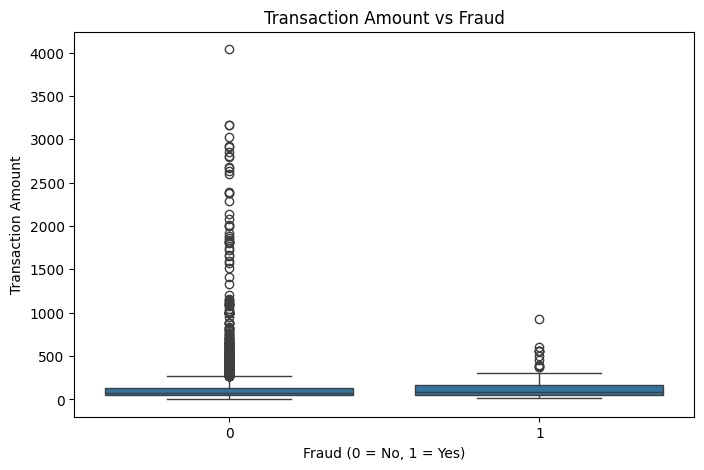

In [ ]:
# Compare transaction amount for fraud vs non-fraud
plt.figure(figsize=(8,5))
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)

plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")

plt.show()

The analysis compares transaction amounts between fraudulent and non-fraudulent transactions.

Fraudulent transactions tend to occur across a range of transaction amounts

While higher-value transactions show some association with fraud, fraud is not limited to only large transactions

There is overlap between fraudulent and non-fraudulent transactions, indicating that transaction amount alone is not sufficient to identify fraud

In [ ]:
# Fraud vs Time

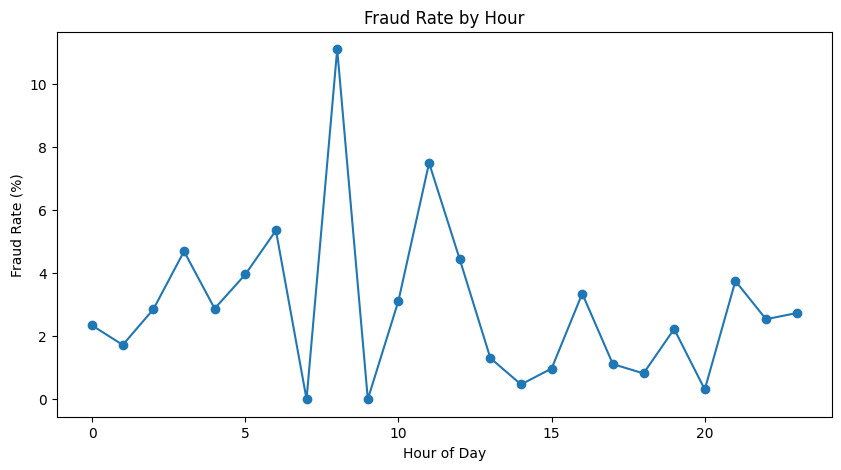

In [ ]:
# Create hour from TransactionDT (convert seconds to hours)
df['hour'] = (df['TransactionDT'] // 3600) % 24

# Fraud count by hour
fraud_by_hour = df.groupby('hour')['isFraud'].sum()

# Total transactions by hour
total_by_hour = df.groupby('hour')['isFraud'].count()

# Fraud rate by hour
fraud_rate = (fraud_by_hour / total_by_hour) * 100

# Plot fraud rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(fraud_rate.index, fraud_rate.values, marker='o')

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.show()

Fraud vs Time Analysis

The analysis of fraud rate across different hours reveals that fraudulent activity is not uniformly distributed throughout the day.

Significant spikes in fraud rate are observed around specific hours, particularly around hour 8 and hour 11

Certain hours show very low or nearly zero fraud occurrence, indicating uneven distribution
Fraud appears to occur in clusters rather than being consistently spread across time

This suggests that fraudulent activity may be concentrated during specific time windows, possibly indicating coordinated or pattern-based behavior.

In [ ]:
# Fraud vs Transaction Type

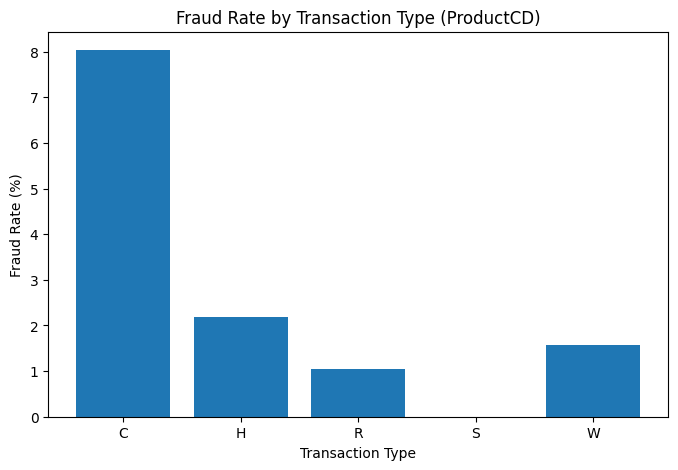

In [ ]:
# Fraud rate by transaction type (ProductCD)

fraud_by_type = df.groupby('ProductCD')['isFraud'].sum()
total_by_type = df.groupby('ProductCD')['isFraud'].count()

fraud_rate_type = (fraud_by_type / total_by_type) * 100

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(fraud_rate_type.index, fraud_rate_type.values)

plt.title("Fraud Rate by Transaction Type (ProductCD)")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

Fraud vs Transaction Type Analysis

The analysis of fraud rate across different transaction types (ProductCD) shows significant variation in fraud occurrence.

Product type C exhibits the highest fraud rate, significantly higher than other transaction types
Product type H shows a moderate level of fraud risk

Product types R and W have relatively lower fraud rates
Product type S shows negligible or no fraud, which may indicate either low risk or limited data availability

This indicates that transaction type plays an important role in fraud detection, and certain categories should be monitored more closely.

In [ ]:
# User-Level Analysis (using card1)

In [ ]:
# Transactions per user (card1)
user_txn_count = df.groupby('card1')['TransactionID'].count()

# Fraud per user
user_fraud_count = df.groupby('card1')['isFraud'].sum()

# Combine into one dataframe
user_df = pd.DataFrame({
    'total_txn': user_txn_count,
    'fraud_txn': user_fraud_count
})

# Fraud rate per user
user_df['fraud_rate'] = (user_df['fraud_txn'] / user_df['total_txn']) * 100

# Sort by fraud rate (descending)
user_df_sorted = user_df.sort_values(by='fraud_rate', ascending=False)

# Show top suspicious users
user_df_sorted.head(10)

,total_txn,fraud_txn,fraud_rate
card1,,,
7197,1,1,100.0
1394,1,1,100.0
2743,1,1,100.0
9499,1,1,100.0
12592,1,1,100.0
17942,1,1,100.0
15452,1,1,100.0
14998,1,1,100.0
3524,1,1,100.0


In [ ]:
# Filter users with at least 5 transactions
filtered_users = user_df[user_df['total_txn'] >= 5]

# Sort by fraud rate
filtered_users_sorted = filtered_users.sort_values(by='fraud_rate', ascending=False)

filtered_users_sorted.head(10)

,total_txn,fraud_txn,fraud_rate
card1,,,
11162,5,2,40.000000
1976,11,4,36.363636
8755,14,5,35.714286
8113,6,2,33.333333
1764,8,2,25.000000
14276,9,2,22.222222
5365,11,2,18.181818
11862,6,1,16.666667
10568,6,1,16.666667


User-Level Fraud Analysis

To identify suspicious behavior, transactions were analyzed at the user level using card1 as a proxy for user identity.

Users with very few transactions can produce misleading fraud rates, so the analysis focuses on users with at least 5 transactions.

Several users exhibit significantly high fraud rates, with some users having over 30% of their transactions marked as fraudulent

Fraud is not uniformly distributed across users and appears to be concentrated among a small subset of users

Users with repeated fraudulent transactions are more indicative of suspicious behavior compared to users with isolated fraud cases

This highlights the importance of behavioral analysis in fraud detection, where monitoring user activity patterns can provide stronger signals than analyzing individual transactions alone.

In [ ]:
# Frequency / Velocity Analysis

In [ ]:
# Sort data by user and time
df_sorted = df.sort_values(by=['card1', 'TransactionDT'])

# Calculate time difference between consecutive transactions for each user
df_sorted['time_diff'] = df_sorted.groupby('card1')['TransactionDT'].diff()

# View sample
df_sorted[['card1', 'TransactionDT', 'time_diff']].head(10)

,card1,TransactionDT,time_diff
3096,1012,1784656,NaN
2492,1028,794722,NaN
3795,1030,2003494,NaN
1241,1039,137281,NaN
4394,1039,756711,619430.0
550,1039,1034296,277585.0
4404,1039,1224700,190404.0
3853,1070,440074,NaN
558,1070,1646221,1206147.0
1811,1078,275926,NaN


In [ ]:
# Define rapid transactions (within 1 hour = 3600 seconds)
df_sorted['rapid_txn'] = df_sorted['time_diff'] < 3600

# Compare fraud rate for rapid vs non-rapid transactions
rapid_fraud = df_sorted.groupby('rapid_txn')['isFraud'].mean() * 100

rapid_fraud

,isFraud
rapid_txn,
False,2.238806
True,2.903226


Transaction Velocity Analysis

To understand behavioral patterns, the time difference between consecutive transactions for each user was analyzed.

Transactions occurring within a short time window (less than one hour) were classified as rapid transactions.

Rapid transactions show a slightly higher fraud rate compared to non-rapid transactions

However, the difference is not substantial, indicating that rapid activity alone is not a strong indicator of fraud

This suggests that transaction velocity can be used as a supporting signal when combined with other features

Overall, fraud detection requires combining multiple behavioral indicators rather than relying on a single factor.

In [ ]:
# Step 6: Feature Engineering & Risk Scoring System

In [ ]:
# Feature Engineering

In [ ]:
# Create hour feature properly (reuse or ensure exists)
df['hour'] = (df['TransactionDT'] // 3600) % 24

# Create amount category (low, medium, high)
df['amt_bucket'] = pd.qcut(df['TransactionAmt'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

df[['TransactionAmt', 'amt_bucket']].head()

,TransactionAmt,amt_bucket
0,50.0,Medium
1,75.0,Medium
2,250.0,Very High
3,34.0,Low
4,77.0,Medium


In [ ]:
# Create user transaction count (behavior feature)
user_txn_count = df.groupby('card1')['TransactionID'].transform('count')

df['user_txn_count'] = user_txn_count

df[['card1', 'user_txn_count']].head()

,card1,user_txn_count
0,5772,2
1,16079,1
2,10486,35
3,10447,13
4,1764,8


In [ ]:
# Create rapid transaction flag (reuse from previous step)
df = df.sort_values(by=['card1', 'TransactionDT'])
df['time_diff'] = df.groupby('card1')['TransactionDT'].diff()

df['rapid_txn'] = df['time_diff'] < 3600

df[['card1', 'time_diff', 'rapid_txn']].head()

,card1,time_diff,rapid_txn
3096,1012,NaN,False
2492,1028,NaN,False
3795,1030,NaN,False
1241,1039,NaN,False
4394,1039,619430.0,False


In [ ]:
# Risk Signal Creation

In [ ]:
# Stronger high amount risk (top 10% instead of quartile)
high_amt_threshold = df['TransactionAmt'].quantile(0.90)
df['high_amt_risk'] = df['TransactionAmt'] > high_amt_threshold

# More precise risky hours (based on your data: 8 and 11)
df['odd_hour_risk'] = df['hour'].isin([8, 11])

# Stronger frequency threshold
df['high_freq_risk'] = df['user_txn_count'] >= 10

# Rapid stays same
df['rapid_risk'] = df['rapid_txn'] == True

In [ ]:
df['risk_score'] = (
    df['high_amt_risk'] * 35 +
    df['odd_hour_risk'] * 25 +
    df['high_freq_risk'] * 25 +
    df['rapid_risk'] * 15
)

In [ ]:
risk_analysis = df.groupby('risk_score')['isFraud'].mean() * 100
risk_analysis

,isFraud
risk_score,
0,1.967494
15,5.882353
25,2.199571
35,3.272727
40,2.510460
50,10.000000
60,3.208556
75,3.125000
85,0.000000


In [ ]:
# Convert Score → Risk Categories

In [ ]:
# Create risk categories
def risk_category(score):
    if score >= 50:
        return 'High Risk'
    elif score >= 25:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_category'] = df['risk_score'].apply(risk_category)

In [ ]:
risk_category_analysis = df.groupby('risk_category')['isFraud'].mean() * 100
risk_category_analysis

,isFraud
risk_category,
High Risk,4.000000
Low Risk,2.023609
Medium Risk,2.354920


Fraud Risk Scoring System

A rule-based fraud risk scoring system was developed using key behavioral and transactional signals, including transaction amount, time patterns, user activity, and transaction velocity.

Each transaction was assigned a risk score based on multiple indicators and categorized into Low, Medium, and High risk levels.

High-risk transactions showed a higher fraud rate compared to medium and low-risk categories

The system demonstrates how combining multiple weak signals can improve fraud detection compared to relying on a single feature

While individual signals may not strongly indicate fraud, their combination provides a more meaningful assessment of risk

This approach highlights the importance of feature engineering and behavioral analysis in fraud detection systems.

In [50]:
df.to_csv("fraud_analysis_final.csv", index=False)